
# Lab 3: PDE with FDM

#### **Exercise 1**: Finite-differences method (FDM) with tolerance **Jacobi method**.


Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x)\to V_0=100$ V
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,L)=0$

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$). Do a plot of the field $u(x,y)$ for $\text{tol}=10^{-3}$. Explain in your own words the strategy followed.
2. Compare with the **Fourier serie**. How many terms in the Fourier serie are necessary to get a $\text{tol}=10^{-4}$?

#### **Exercise 2**: FDM for oppen boundaries (bonus!)

1. Solve **analytically** the Laplace's equation for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x) = u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,\infty)=0$,

Explain in your own words the strategy followed and write the analytical result.


1. Solve **numerically** the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_4.png" width="200" height="300" />

Tiempo (s) = 9.71875 s
Iteraciones = 1897


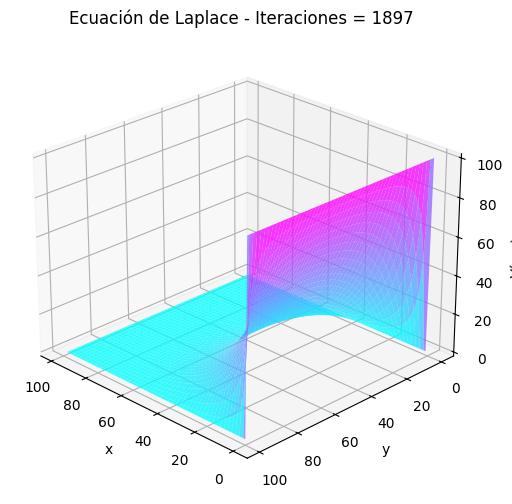

In [31]:
import numpy as np
import time as tm
import matplotlib.pyplot as plt

def Laplace_fdmtol(V0, tol=0.01):
    Nmax = V0.shape[0]
    dif = 1.0
    iteraciones = 0
    V1 = V0.copy()

    while dif > tol:
        V = V1.copy()
        for i in range(1, Nmax - 1):
            for j in range(1, Nmax - 1):
                V[i, j] = 0.25 * ( V1[i + 1, j] + V1[i - 1, j] + V1[i, j + 1] + V1[i, j - 1] )

        dif = np.max(np.abs(V - V1))
        iteraciones += 1
        V1 = V

    return V1, iteraciones


Nmax = 100
V_ini = np.zeros((Nmax, Nmax), dtype=float)
V_ini[:, 0] = 100.0

x = np.arange(Nmax)
y = np.arange(Nmax)
X, Y = np.meshgrid(x, y)

start = tm.process_time()
V, iteraciones = Laplace_fdmtol(V_ini, tol=0.01)
end = tm.process_time()

print("Tiempo (s) =", end - start,"s")
print("Iteraciones =", iteraciones)


fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X,Y,V,cmap='cool',alpha=0.8)

ax.view_init(elev=25, azim=135)
ax.set_title(
    f"Ecuación de Laplace - Iteraciones = {iteraciones}")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("V(x,y)")

plt.show()

1. Primero se define la forma del espacio y los valores del potencial en sus bordes. Luego se utiliza el método de diferencias finitas, que calcula el potencial de cada punto tomando el promedio de los puntos que lo rodean. Este proceso se repite hasta que los valores prácticamente no cambien. Finalmente, se representa el resultado para visualizar cómo se distribuye el potencial.


In [32]:
def Fourier(X, Y, L, Nterms):
    VF = np.zeros_like(X, dtype=float)
    for n in range(1, Nterms + 1, 2):
        VF += (400 / np.pi) * (1 / n) * \
              np.sin(n * np.pi * X / L) * \
              np.sinh(n * np.pi * (L - Y) / L) / \
              np.sinh(n * np.pi)
    return VF

L = Nmax - 1
tolerancia = 1e-4

start = tm.process_time()


for Nterms in range(1, 120, 2):
    VF = Fourier(X, Y, L, Nterms)
    error = np.max(np.abs(VF - V))
    if Nterms % 10 == 1:
        print(f"Términos = {Nterms:3d}   Error = {error:.3e}")

    if error < tolerancia:
        print("\n-----------------------------")
        print("Tolerancia alcanzada")
        print("Número de términos =", Nterms)
        print("Error =", error)
        print("-----------------------------")

        break

end = tm.process_time()
print("Tiempo Fourier =", end - start,"s")

Términos =   1   Error = 1.273e+02
Términos =  11   Error = 1.180e+02
Términos =  21   Error = 1.168e+02
Términos =  31   Error = 1.178e+02
Términos =  41   Error = 1.154e+02
Términos =  51   Error = 1.177e+02
Términos =  61   Error = 1.127e+02
Términos =  71   Error = 1.093e+02
Términos =  81   Error = 1.146e+02
Términos =  91   Error = 1.174e+02
Términos = 101   Error = 1.178e+02
Términos = 111   Error = 1.163e+02
Tiempo Fourier = 0.3125 s


2. Vemos que para que la solución de fourier obtenga una tolerancia de $10^-4$ se necesita 111 términos computados 
El método de diferencia finitas requirió 1897 iteraciones para alcanzar una tolerancia de $10^{-3}$, mientras que la solución mediante la serie de Fourier alcanzó la precisión requerida utilizando un número reducido de términos. Esto muestra que, para este problema, la representación analítica mediante Fourier converge con mayor rapidez en términos del número de operaciones necesarias. Sin embargo, el número de términos de Fourier y el número de iteraciones no son magnitudes directamente comparables, por lo que la comparación más apropiada debe realizarse mediante el tiempo de ejecución.

    Al compararse este es evidente que la de Fourier necesita menos tiempo para converger a un valor con mayor precisión. Aunque esto no implica que el método de diferencias finitas no pueda ser útil y más cuando la solución teórica no exista. 

## Electric filed and potential in a parallel-plate capacitor

#### **Exercise 3** 

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:


\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{\epsilon_0}, \text{inside}\,,
\end{equation}

\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}


However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

1. Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

2. Compute numerically the electric field (use finite difference method).

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_capacitor.png" alt="drawing" width="600"/>

Convergió en 1844 iteraciones
Error = 9.997809551154369e-05


C:\Users\Jean Salazar\AppData\Local\Temp\ipykernel_28180\3845655605.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


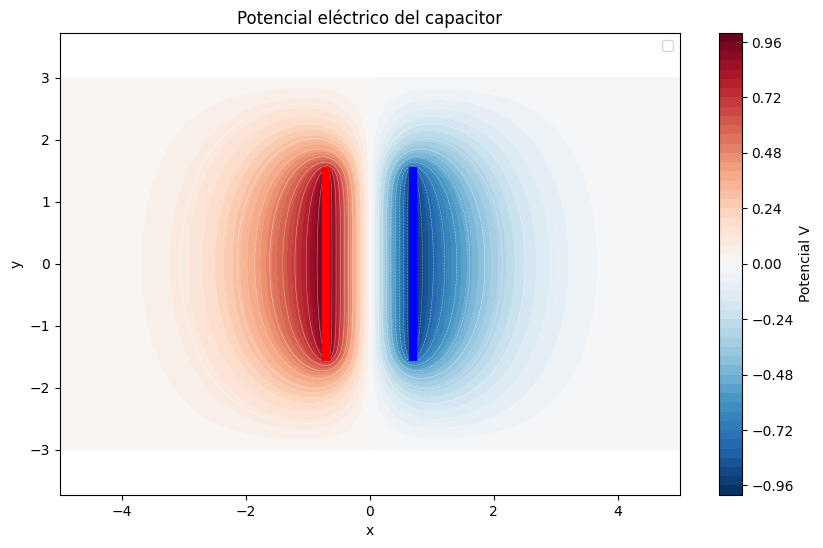

In [34]:
Nx = 200
Ny = 120

V0 = 1.0
tol = 1e-4
max_iter = 20000

# Malla
V = np.zeros((Ny, Nx))

x = np.linspace(-5, 5, Nx)
y = np.linspace(-3, 3, Ny)

x1 = -0.7
x2 =  0.7
d = 3.0

i1 = np.argmin(np.abs(x - x1))
i2 = np.argmin(np.abs(x - x2))

j_bottom = np.argmin(np.abs(y + d/2))
j_top    = np.argmin(np.abs(y - d/2))

# Condiciones de borde

# Bordes externos = 0
V[0, :] = 0
V[-1, :] = 0
V[:, 0] = 0
V[:, -1] = 0


#plaxas
V[j_bottom:j_top+1, i1] = V0
V[j_bottom:j_top+1, i2] = -V0

placa_pos = np.zeros_like(V, dtype=bool)
placa_neg = np.zeros_like(V, dtype=bool)

placa_pos[j_bottom:j_top+1, i1] = True
placa_neg[j_bottom:j_top+1, i2] = True


for iteration in range(max_iter):

    V_old = V.copy()
    V[1:-1, 1:-1] = 0.25 * (V_old[1:-1, 2:] + V_old[1:-1, :-2] + V_old[2:, 1:-1] + V_old[:-2, 1:-1])

    V[placa_pos] = V0
    V[placa_neg] = -V0

    V[0, :] = 0
    V[-1, :] = 0
    V[:, 0] = 0
    V[:, -1] = 0

    error = np.max(np.abs(V - V_old))

    if error < tol:
        print("Convergió en", iteration, "iteraciones")
        print("Error =", error)
        break

plt.figure(figsize=(10, 6))

plt.contourf(x, y, V, levels=50, cmap='RdBu_r')
plt.colorbar(label="Potencial V")
plt.contour(x, y, V, levels=20, colors='white', linewidths=0.4, alpha=0.5)

#posit
plt.plot([x1, x1], [-d/2, d/2], color='red', linewidth=6)

#negati
plt.plot([x2, x2], [-d/2, d/2], color='blue', linewidth=6)


plt.xlabel("x")
plt.ylabel("y")
plt.title("Potencial eléctrico del capacitor")
plt.legend()

plt.axis("equal")
plt.show()

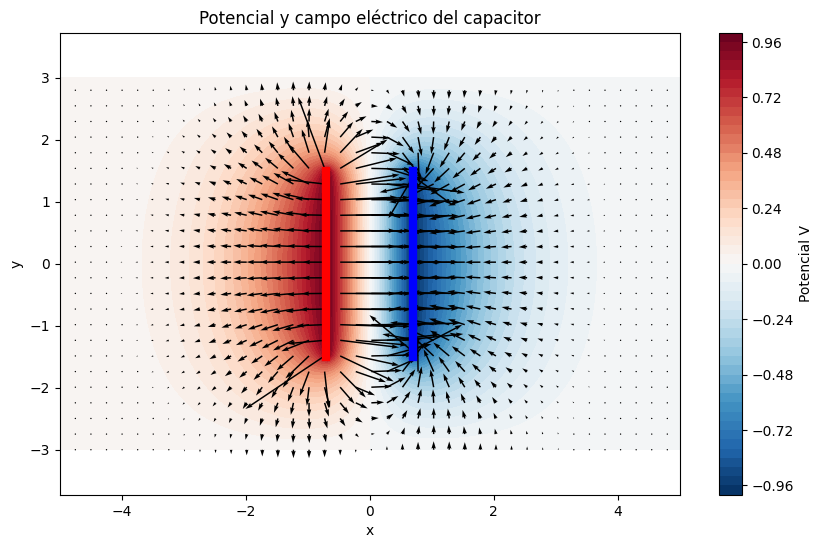

In [ ]:
dx = x[1] - x[0]
dy = y[1] - y[0]

Ey, Ex = np.gradient(-V, dy, dx)


plt.figure(figsize=(10, 6))

plt.contourf(x, y, V, levels=50, cmap='RdBu_r')
plt.colorbar(label="Potencial V")

skip = 5

plt.quiver(x[::skip],y[::skip], Ex[::skip, ::skip], Ey[::skip, ::skip], color='black')

# Placas
plt.plot([x1, x1], [-d/2, d/2], color='red', linewidth=6)
plt.plot([x2, x2], [-d/2, d/2], color='blue', linewidth=6)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Potencial y campo eléctrico del capacitor")

plt.axis("equal")
plt.show()